# L4: Advanced topics
# Identifying Friction in Turbomachinery Structures with a Switching Gaussian Process Latent Force Model and Physics-Enhanced Sparse Identification strategy

**A hands-on tutorial , using the real experimental data of Marino & Cicirello (2023), *Data-Centric Engineering* 4, e18.**


---
**file name:** L4_friction_identification_switching_GPLFM.ipynb

Part of Lecture 2 - second notebook

**Instructor:** Alice Cicirello

**Generated for Training school scientific machine learning for digital twins**


**The first draft version of the notebook was generated using Anthropic's Claude**

**Date**: September 2026

**Last Modifications and checks made by Alice Cicirello on: 5/09/2026**

---


## Why should a turbomachinery engineer care about friction?

Gas-turbine and aero-engine bladed discs are *assembled* structures. Wherever two metal parts are pressed together and vibrate, a **frictional contact** exists:

| Contact location | Role of friction |
|---|---|
| Blade root / dovetail and fir-tree joints | Micro-slip dissipates energy, but also causes fretting-fatigue |
| **Underplatform dampers** | Deliberately added metal pieces that dissipate vibratory energy by rubbing |
| Shroud and snubber interfaces | Couple adjacent blades through a friction interface |
| Bolted flanges in casings and rotors | Damping and (undesired) nonlinear stiffness |

Friction is the **dominant source of damping** in blisks and bladed discs, and resonant stresses at high-cycle-fatigue-critical modes depend directly on it (Schwingshackl et al., 2012; Krack et al., 2017). Forced-response predictions with tools such as the harmonic balance method (Krack & Gross, 2019) need a **friction law** — e.g. a Coulomb friction coefficient, or a velocity-dependent law — and its parameters at the contact. These parameters **cannot be measured directly**: you cannot put a force sensor *inside* a blade-root contact. They must be **identified from vibration measurements**.

This is hard because friction makes the system **nonlinear, non-smooth and discontinuous**:

* the friction force jumps when the sliding velocity changes sign;
* the system alternates between **stick** (contact locked) and **slip** (contact sliding) — different governing equations in each regime;
* classical linear identification (FRFs, modal analysis) is not applicable.

## What you will learn

1. How a **Gaussian process latent force model (GPLFM)** combines a *partially known* physics model with noisy measurements to infer an unknown force as a Bayesian state — the "grey-box" approach.
2. Why friction needs a **switching** GPLFM — several latent force models (slide / stick / reset) with a hidden Markov chain — and how to run its inference with Kalman-filter machinery.
3. How to apply this to the **real laboratory data** of Marino & Cicirello (2023): a base-excited single-storey frame with a brass-to-steel contact — a laboratory analogue of a friction-damped blade.
4. How to **assess the results with error metrics** (NMSE, NMV, forward-prediction error).
5. How to extract *usable engineering outputs*: friction coefficient, static friction force, a fitted friction law, and energy dissipated per cycle.
6. How a **state-of-the-art alternative** — physics-informed sparse regression (PhI-SINDy, Lathourakis & Cicirello, 2024, building on SINDy, Brunton et al., 2016) — solves the same problem, and how the two strategies compare.

> **Prerequisites:** SDOF vibration theory, basic probability, and having met a Kalman filter once. Everything else is introduced as we go.

> **Sources.** The method and the experimental campaign are from Marino & Cicirello (2023) — equations below are cross-referenced to that paper as *(MC-Eq. n)*. The data files are those published by the authors at [github.com/l-marino/switching-GPLFM](https://github.com/l-marino/switching-GPLFM). A full reference list is at the end.

In [1]:
import os, urllib.request
import numpy as np
import scipy.linalg as sla
from scipy.io import loadmat
from scipy.optimize import minimize, curve_fit
from scipy.integrate import solve_ivp
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.3, 'lines.linewidth': 1.0})
print("Libraries loaded.")

Libraries loaded.


## 1. The case study: a laboratory friction-damped structure

The experimental rig (Marino & Cicirello, 2020; 2023, §4.1) is a **single-storey frame**: two steel plates connected by four thin, doubly-bolted metal bars. The bottom plate is driven harmonically by a Scotch-yoke mechanism (an electric motor turning a crank), and a **brass disc pressed onto the top steel plate** by an adjustable counterweight system creates a **metal-to-metal friction contact** — exactly the situation of a friction damper rubbing on a blade platform. Laser position sensors measure the displacement of both plates.

For driving frequencies up to ~8 Hz the frame behaves as a **single-degree-of-freedom (SDOF) base-excited oscillator with a friction contact** *(MC-Eq. 34)*:

$$m\,\ddot z + c\,\dot z + k\,z + F_f(z,\dot z) = k\,u(t) + c\,\dot u(t)$$

where $z(t)$ is the top-plate displacement, $u(t)$ the measured base (bottom-plate) displacement, and $F_f$ the **unknown friction force** we want to identify. Note the input involves both $u$ and $\dot u$, and only $u$ is measured (noisily).

**Known parameters** (from a hammer test with the contact removed, MC-Table 7): the mass is $m = 3.0799$ kg. The hammer test also gives reference values $k \approx 1197$ N/m, $c \approx 0.30$ Ns/m ($f_n = 3.14$ Hz, $\zeta = 0.0018$) — but we will pretend, as in the paper, that we only have rough initial guesses $\hat k = 1250$ N/m, $\hat c = 5$ Ns/m, and let the method correct them. (The mass is *not identifiable* from base-excitation data — see MC-§4.1 — so it must be known.)

**Data sets:** four records of 10 s at $f_s = 250$ Hz, one per applied normal load. The disc + counterweight settings give normal forces of approximately 2.5, 3.4, 4.4 and 5.4 N (disc weights 250–550 g).

We start with the **550 g (≈ 5.4 N normal load)** record, the same one analysed in MC-§4.2 with a fundamental driving frequency of 1 Hz.

downloading s_b_250g_x.mat
downloading s_b_250g_y.mat
downloading s_b_350g_x.mat
downloading s_b_350g_y.mat
downloading s_b_450g_x.mat
downloading s_b_450g_y.mat
downloading s_b_550g_x.mat
downloading s_b_550g_y.mat
record: 10.0 s at 250 Hz  (2501 samples)


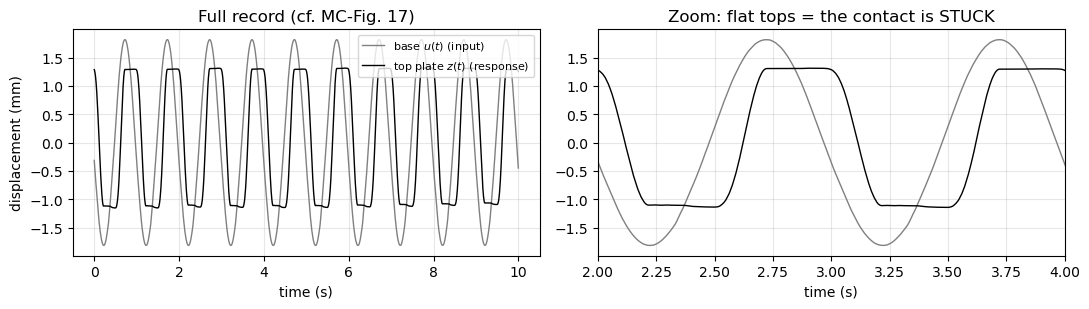

In [2]:
# --- Download the authors' experimental data (once) and load a record
DATA_DIR = "sgplfm_data"
BASE_URL = ("https://raw.githubusercontent.com/l-marino/switching-GPLFM/main/"
            "Single-storey%20frame/Experimental%20data/")
os.makedirs(DATA_DIR, exist_ok=True)
for wgt in (250, 350, 450, 550):
    for ax in ("x", "y"):
        fname = f"s_b_{wgt}g_{ax}.mat"
        fpath = os.path.join(DATA_DIR, fname)
        if not os.path.exists(fpath):
            print("downloading", fname)
            urllib.request.urlretrieve(BASE_URL + fname, fpath)

def load_case(weight):
    '''Load one experimental record. Returns t (s), z = top plate (m), u = base (m).
    File convention (authors' switching_GPLFM_main.m): x = top plate, y = bottom plate, mm.'''
    dx = loadmat(os.path.join(DATA_DIR, f"s_b_{weight}g_x.mat"))
    dy = loadmat(os.path.join(DATA_DIR, f"s_b_{weight}g_y.mat"))
    t = dx["t"].squeeze(); t = t - t[0]
    z = 1e-3*dx["x"].squeeze()      # top-plate displacement (m)  - the response
    u = 1e-3*dy["y"].squeeze()      # bottom-plate displacement (m) - the base input
    return t, z, u

t, z_obs, u_noisy = load_case(550)
dt = t[1] - t[0]; fs = 1/dt; T = len(t)
print(f"record: {t[-1]:.1f} s at {fs:.0f} Hz  ({T} samples)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(t, 1e3*u_noisy, color='0.5', label='base $u(t)$ (input)')
ax[0].plot(t, 1e3*z_obs, 'k', label='top plate $z(t)$ (response)')
ax[0].set(xlabel='time (s)', ylabel='displacement (mm)', title='Full record (cf. MC-Fig. 17)')
ax[0].legend(loc='upper right', fontsize=8)
ax[1].plot(t, 1e3*u_noisy, color='0.5'); ax[1].plot(t, 1e3*z_obs, 'k')
ax[1].set(xlim=(2, 4), xlabel='time (s)', title='Zoom: flat tops = the contact is STUCK')
plt.tight_layout(); plt.show()

### Reading the measured response like a friction specialist

The base moves as a smooth 1 Hz sine, but the top plate shows a distinctive **"two-stops-per-cycle" stick–slip motion**: the flat plateaus are intervals where the friction contact is **stuck** (velocity exactly zero — the friction force balances the elastic force), and the steep ramps are **slip** phases. This is the fingerprint of Coulomb-type friction:

$$F_f(z, \dot z) = \begin{cases} F_c \,\mathrm{sgn}(\dot z) & \dot z \neq 0 \quad \text{(kinetic, sliding)}\\ \text{whatever balances the other forces, } |F_f| \le F_s & \dot z = 0 \quad \text{(static, stuck)} \end{cases}$$

with kinetic friction force $F_c = \mu_k N$ and static friction force $F_s = \mu_s N \ge F_c$ for normal load $N$. During a stick phase the friction force is **not constant** — it continuously adjusts to balance $k(u-z) + c\dot u$, until it hits the static limit $\pm F_s$ and the contact breaks away. The force is **discontinuous** at slip reversals (it jumps by $2F_c$).

**Why identification is hard:** the quantity we want, $F_f(t)$, enters the equation of motion as an *unmeasured input*, switches governing regime, and jumps. A single smooth model (a linear filter, a plain GP, a polynomial fit) cannot represent it well. This motivates the switching GPLFM.

## 2. Theory I — the Gaussian process latent force model (GPLFM)

### 2.1 The idea

A **latent force model** (Alvarez et al., 2009) treats the unknown force as a random function with a GP prior,

$$f(t) \sim \mathcal{GP}\big(0,\ \kappa(t, t')\big),$$

and lets Bayes' rule update it using (i) the measured response and (ii) the *known physics* — here the SDOF equation of motion. We do not assume any functional form $F_f(z,\dot z)$; the GP only encodes that the force has finite variance $\sigma_f^2$ and a correlation time-scale $\ell$.

### 2.2 The kernel and its state-space form

The **Matérn** family *(MC-Eq. 7)* is used because it has an exact state-space representation (Hartikainen & Särkkä, 2010; Särkkä & Solin, 2019). Following the paper we take the roughest member, $\nu = 1/2$ (the *exponential* kernel):

$$\kappa(t,t') = \sigma_f^2 \exp\!\left(-\frac{|t-t'|}{\ell}\right)
\quad\Longleftrightarrow\quad
\dot f(t) = -\frac{1}{\ell} f(t) + w(t), \qquad w \sim \text{white noise, spectral density } q = \frac{2\sigma_f^2}{\ell}$$

*(MC-Eq. 8)*. A GP in time is equivalent to a linear stochastic differential equation (SDE) — this is the trick that turns GP regression ($O(T^3)$) into Kalman filtering ($O(T)$).

### 2.3 Augmenting the structure with the latent force

Write the SDOF structure in state-space form with state $\mathbf{z} = [z, \dot z]^\top$. For our base-excited system *(MC-Eqs. 34–35)*, with input $\mathbf{u} = [u, \dot u]^\top$:

$$A_{c,s} = \begin{bmatrix} 0 & 1 \\ -k/m & -c/m \end{bmatrix}, \qquad
B_{c,s} = \begin{bmatrix} 0 & 0 \\ k/m & c/m \end{bmatrix},$$

and the friction force enters the acceleration row with coefficient $-1/m$. Stacking $\mathbf{x} = [z, \dot z, f]^\top$ gives the **augmented model** *(MC-Eqs. 10–11)*:

$$\dot{\mathbf{x}} = A_c\,\mathbf{x} + B_c\,\mathbf{u} + L_c\, w, \qquad
A_c = \begin{bmatrix} 0 & 1 & 0\\ -k/m & -c/m & -1/m \\ 0 & 0 & -1/\ell \end{bmatrix},\quad
B_c = \begin{bmatrix} 0&0 \\ k/m & c/m \\ 0&0\end{bmatrix},\quad
L_c = \begin{bmatrix} 0\\0\\1 \end{bmatrix}.$$

Discretising with time step $\Delta t$ (zero-order hold) gives $\mathbf{x}_t = A \mathbf{x}_{t-1} + B \mathbf{u}_{t-1} + \mathbf{w}_{t-1}$, $\mathbf{w} \sim \mathcal N(0, Q)$ *(MC-Eq. 12)*, where $A = \exp_m(A_c \Delta t)$ and $Q$ is obtained from the stationary covariance $P_\infty$ solving the Lyapunov equation $A_c P_\infty + P_\infty A_c^\top + L_c q L_c^\top = 0$ via $Q = P_\infty - A P_\infty A^\top$ *(MC-Eqs. 14–15)*. The observation is the (noisy) top-plate displacement *(MC-Eq. 16)*:

$$y_t = C\,\mathbf{x}_t + v_t, \qquad C = [1, 0, 0], \qquad v_t \sim \mathcal N(0, \sigma_n^2).$$

With everything linear-Gaussian, a **Kalman filter + RTS smoother** infers $z, \dot z$ *and the force* $f$ jointly — this is the standard GPLFM (Nayek et al., 2019; Rogers et al., 2020).

## 3. Theory II — the *switching* GPLFM

A single GP cannot represent a force that jumps and changes regime. Marino & Cicirello use **$S = 3$ latent force models** inside a *switching linear dynamical system* (SLDS), with a hidden discrete state $s_t \in \{1,2,3\}$:

1. **Sliding model** ($s=1$): the augmented model of §2.3 — friction evolves as a GP.
2. **Sticking model** ($s=2$): physics says $\dot z = 0$, $z$ frozen, and the friction force balances the elastic + damping forces. Its prediction density *(MC-Eqs. 22–23, adapted to base excitation)* is
$$\mu_{t|t-1} = \big[\,\mathbb E(z_{t-1}),\ 0,\ k u_{t-1} + c \dot u_{t-1} - k\,\mathbb E(z_{t-1})\,\big]^\top .$$
3. **Resetting model** ($s=3$): a "discontinuity generator" (Hartikainen & Särkkä, 2012). For one time step the force is *reset* to a zero-mean prior $\mathcal N(0, P_0)$ ($P_0 = 0.05$ N²) while $z,\dot z$ evolve unaffected; transition matrix $A^{(3)} = \mathrm{blkdiag}(\exp_m(A_{c,s}\Delta t), 0)$. This lets the identified force **jump** at stick–slip transitions and velocity reversals.

The regime sequence has a Markov-chain prior *(MC-Eq. 4)* with persistence $\rho = 0.92$: a model stays active with probability $\rho$, otherwise it hands over to the resetting model, which immediately hands over to one of the others with equal probability. **Transitions between slide and stick always pass through a one-step reset** — that is how discontinuities appear.

### Inference: assumed density filtering + expectation correction

Exact inference in an SLDS costs $O(S^T)$ — intractable. The paper uses the Gaussian-sum approach of Barber (2006): **assumed density filtering (ADF)** approximates the filtered posterior of each model by a mixture of $I$ Gaussians *(MC-Eq. 17)*, and **expectation correction (EC)** produces smoothed mixtures with $J$ components *(MC-Eq. 18)*; the paper uses $I=J=3$.

> **Simplification in this notebook.** We implement ADF/EC with **one Gaussian per regime** ($I=J=1$, a "GPB2-style" collapse). At each step we (i) propagate all $S^2$ regime pairs with a Kalman prediction/update, (ii) weight them by the Markov prior and their likelihood, and (iii) moment-match back to one Gaussian per regime. The backward EC pass mirrors this with RTS updates and Barber's "mean approximation" overlap weights. This keeps every line of code inspectable while retaining the full switching structure; the authors' MATLAB code implements the full mixture version.

### Hyperparameters

Three hyperparameters remain: $\boldsymbol\theta = (\sigma_f^2, \ell, \sigma_n^2)$. The ADF pass returns the **log marginal likelihood** $\log p(y_{1:T} \mid \boldsymbol\theta)$ as a by-product, so we can optimise it. The paper infers a full posterior with **Variational Bayes Monte Carlo** (VBMC, Acerbi, 2018) and uses the posterior mean; we use direct maximum-likelihood optimisation (Nelder–Mead in $\log\theta$) for simplicity — same objective, point estimate instead of posterior.

In [3]:
# --- The three latent force models (MC-Eqs. 4-16, 22-23, 34-35) -------------
def build_models(theta, M, C, K, dt, P0_reset=0.05):
    '''Discrete-time matrices (A, B, Q) of the S=3 latent force models.
    State x = [z, zdot, f]; input u = [u, udot]; y = z + noise.
    theta = (sig_f2 [N^2], ell [s], sig_n2 [m^2]).'''
    sig_f2, ell, sig_n2 = theta
    Acs = np.array([[0.0, 1.0], [-K/M, -C/M]])          # structure (MC-Eq. 9)
    Bcs = np.array([[0.0, 0.0], [K/M, C/M]])            # base-excitation input (MC-Eq. 35)

    # ---- model 1: SLIDING - augmented GP latent force (MC-Eqs. 10-11)
    Ac = np.zeros((3, 3)); Ac[:2, :2] = Acs; Ac[1, 2] = -1.0/M; Ac[2, 2] = -1.0/ell
    Bc = np.zeros((3, 2)); Bc[:2] = Bcs
    L = np.array([[0.0], [0.0], [1.0]]); q = 2.0*sig_f2/ell   # Matern 1/2 (MC-Eq. 8)
    Maug = np.zeros((5, 5)); Maug[:3, :3] = Ac; Maug[:3, 3:] = Bc
    Ed = sla.expm(Maug*dt)                               # zero-order-hold discretisation
    A1, B1 = Ed[:3, :3], Ed[:3, 3:]
    Pinf = sla.solve_continuous_lyapunov(Ac, -(L*q) @ L.T)    # (MC-Eq. 15)
    Q1 = Pinf - A1 @ Pinf @ A1.T                              # (MC-Eq. 14)
    Q1 = 0.5*(Q1 + Q1.T) + 1e-14*np.eye(3)

    # ---- model 2: STICKING - z frozen, zdot = 0, f balances elastic force (MC-Eqs. 22-23)
    A2 = np.array([[1.0, 0, 0], [0, 0, 0], [-K, 0, 0]])
    B2 = np.array([[0.0, 0], [0, 0], [K, C]])
    Q2 = np.diag([1e-13, 1e-9, 1e-4])   # small slack: real stops are not perfectly rigid

    # ---- model 3: RESETTING - force reset to N(0, P0), states evolve friction-free
    Ms = np.zeros((4, 4)); Ms[:2, :2] = Acs; Ms[:2, 2:] = Bcs
    Es = sla.expm(Ms*dt)
    A3 = np.zeros((3, 3)); A3[:2, :2] = Es[:2, :2]
    B3 = np.zeros((3, 2)); B3[:2] = Es[:2, 2:]
    Q3 = np.zeros((3, 3))
    Q3[:2, :2] = Pinf[:2, :2] - A3[:2, :2] @ Pinf[:2, :2] @ A3[:2, :2].T
    Q3[2, 2] = P0_reset
    Q3 = 0.5*(Q3 + Q3.T) + 1e-14*np.eye(3)

    H = np.array([[1.0, 0.0, 0.0]])     # we measure displacement only (MC-Eq. 16)
    return [(A1, B1, Q1), (A2, B2, Q2), (A3, B3, Q3)], H, sig_n2


def markov_matrix(rho=0.92, S=3):
    '''Regime transition prior (MC-Eq. 4). Pi[i, j] = p(s_t = j | s_{t-1} = i).'''
    Pi = np.zeros((S, S))
    for i in range(S - 1):
        Pi[i, i] = rho; Pi[i, S-1] = 1.0 - rho
    Pi[S-1, :S-1] = 1.0/(S - 1)
    return Pi

print(markov_matrix())

[[0.92 0.   0.08]
 [0.   0.92 0.08]
 [0.5  0.5  0.  ]]


In [4]:
# --- Switching inference: ADF filter + EC smoother (Barber 2006, single-Gaussian) ---
def adf_filter(y, U, models, H, R, Pi, m0, P0):
    '''Assumed density filtering with one Gaussian per regime (I=1).
    Returns per-regime filtered means/covs, regime weights, log marginal likelihood.'''
    S = len(models); N = len(y); n = len(m0)
    mf = np.zeros((N, S, n)); Pf = np.zeros((N, S, n, n)); w = np.zeros((N, S))
    ll = 0.0
    m_prev = np.tile(m0, (S, 1)); P_prev = np.tile(P0, (S, 1, 1))
    w_prev = np.full(S, 1.0/S)
    for k in range(N):
        mm = np.zeros((S, S, n)); PP = np.zeros((S, S, n, n)); lw = np.full((S, S), -np.inf)
        for i in range(S):              # regime at t-1
            if w_prev[i] < 1e-12: continue
            for j in range(S):          # regime at t
                if Pi[i, j] <= 0: continue
                A, B, Q = models[j]
                if k == 0:
                    mp, Pp = m_prev[i], P_prev[i]
                else:
                    mp = A @ m_prev[i] + B @ U[k-1]
                    Pp = A @ P_prev[i] @ A.T + Q
                Sv = (H @ Pp @ H.T)[0, 0] + R
                if not np.isfinite(Sv) or Sv <= 0: continue
                v = y[k] - (H @ mp)[0]
                lik = -0.5*(np.log(2*np.pi*Sv) + v*v/Sv)
                Kg = (Pp @ H.T)/Sv
                mm[i, j] = mp + Kg[:, 0]*v
                Pu = Pp - Kg @ H @ Pp
                PP[i, j] = 0.5*(Pu + Pu.T)
                lw[i, j] = np.log(w_prev[i]) + np.log(Pi[i, j]) + lik
        c = lw.max()
        if not np.isfinite(c):          # numerical breakdown for extreme hyperparameters
            return mf, Pf, w, -np.inf
        wij = np.exp(lw - c); tot = wij.sum()
        ll += c + np.log(tot)           # log marginal likelihood accumulates here
        wij /= tot
        for j in range(S):              # collapse the mixture over i (moment matching)
            wj = wij[:, j].sum(); w[k, j] = wj
            if wj < 1e-12:
                mf[k, j] = m_prev.mean(axis=0); Pf[k, j] = np.eye(n); continue
            wi = wij[:, j]/wj
            mbar = (wi[:, None]*mm[:, j]).sum(axis=0)
            Pbar = np.zeros((n, n))
            for i in range(S):
                if wi[i] > 0:
                    d = (mm[i, j] - mbar)[:, None]
                    Pbar += wi[i]*(PP[i, j] + d @ d.T)
            mf[k, j] = mbar; Pf[k, j] = Pbar
        m_prev, P_prev, w_prev = mf[k], Pf[k], w[k]
    return mf, Pf, w, ll


def ec_smoother(y, U, models, H, R, Pi, mf, Pf, w):
    '''Expectation-correction smoothing (Barber 2006), single Gaussian per regime (J=1),
    with the "mean approximation" for the backward mixture weights.'''
    N, S, n = mf.shape
    ms = mf.copy(); Ps = Pf.copy(); ws = w.copy()
    for k in range(N-2, -1, -1):
        mm = np.zeros((S, S, n)); PP = np.zeros((S, S, n, n)); lw = np.full((S, S), -np.inf)
        for j in range(S):              # regime at t+1
            if ws[k+1, j] < 1e-12: continue
            A, B, Q = models[j]
            for i in range(S):          # regime at t
                if Pi[i, j] <= 0 or w[k, i] < 1e-12: continue
                mp = A @ mf[k, i] + B @ U[k]
                Pp = A @ Pf[k, i] @ A.T + Q
                Pp = 0.5*(Pp + Pp.T) + 1e-14*np.eye(n)
                Ct = Pf[k, i] @ A.T                      # cross-covariance
                G = Ct @ np.linalg.inv(Pp)               # RTS smoother gain
                mu = mf[k, i] + G @ (ms[k+1, j] - mp)
                Pu = Pf[k, i] + G @ (Ps[k+1, j] - Pp) @ G.T
                mm[i, j] = mu; PP[i, j] = 0.5*(Pu + Pu.T)
                # Barber's weight: Pi * filtered weight * Gaussian overlap of smoothed
                # x_{t+1} with this branch's prediction
                Pov = Pp + Ps[k+1, j]
                d = ms[k+1, j] - mp
                sign, logdet = np.linalg.slogdet(2*np.pi*Pov)
                ov = -0.5*(logdet + d @ np.linalg.solve(Pov, d))
                lw[i, j] = np.log(Pi[i, j]) + np.log(w[k, i]) + ov
        wij = np.zeros((S, S))
        for j in range(S):
            if ws[k+1, j] < 1e-12: continue
            col = np.exp(lw[:, j] - lw[:, j].max())
            col[~np.isfinite(col)] = 0
            if col.sum() <= 0: continue
            wij[:, j] = ws[k+1, j]*col/col.sum()
        wsk = np.maximum(wij.sum(axis=1), 0)
        wsk = wsk/wsk.sum() if wsk.sum() > 0 else w[k].copy()
        for i in range(S):
            ws[k, i] = wsk[i]
            if wsk[i] < 1e-12 or wij[i, :].sum() <= 0:
                ms[k, i], Ps[k, i] = mf[k, i], Pf[k, i]; continue
            wj = wij[i, :]/wij[i, :].sum()
            mbar = (wj[:, None]*mm[i]).sum(axis=0)
            Pbar = np.zeros((n, n))
            for j in range(S):
                if wj[j] > 0:
                    d = (mm[i, j] - mbar)[:, None]
                    Pbar += wj[j]*(PP[i, j] + d @ d.T)
            ms[k, i] = mbar; Ps[k, i] = Pbar
    return ms, Ps, ws


def collapse_mixture(ms, Ps, ws):
    '''Overall mean/cov from the per-regime Gaussians (moment matching).'''
    N, S, n = ms.shape
    m = (ws[:, :, None]*ms).sum(axis=1)
    P = np.zeros((N, n, n))
    for s in range(S):
        d = ms[:, s, :] - m
        P += ws[:, s, None, None]*(Ps[:, s] + d[:, :, None]*d[:, None, :])
    return m, P

print("Inference machinery defined.")

Inference machinery defined.


## 4. Step 1 — recover the base motion $u(t), \dot u(t)$

The equation of motion needs the base **velocity** too, but only noisy base *displacement* is measured. Following MC-Eq. 38, we model the base motion with a constant-acceleration random-walk state-space model,

$$\begin{bmatrix} u_t \\ \dot u_t \end{bmatrix} =
\begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}
\begin{bmatrix} u_{t-1} \\ \dot u_{t-1}\end{bmatrix} +
\begin{bmatrix} \tfrac12 \Delta t^2 \\ \Delta t\end{bmatrix} a_{t-1},
\qquad a_{t-1} \sim \mathcal N(0, \sigma_a^2),
\qquad y_{u,t} = u_t + v_{u,t},$$

estimate $(\sigma_a^2, \sigma_u^2)$ by maximising the Kalman-filter marginal likelihood, and take the RTS-smoothed states. This is the same grey-box trick in miniature — a nice warm-up exercise.

base-motion hyperparameters: sigma_a^2 = 1.338e-02 (m/s^2)^2, sigma_u^2 = 5.256e-13 m^2


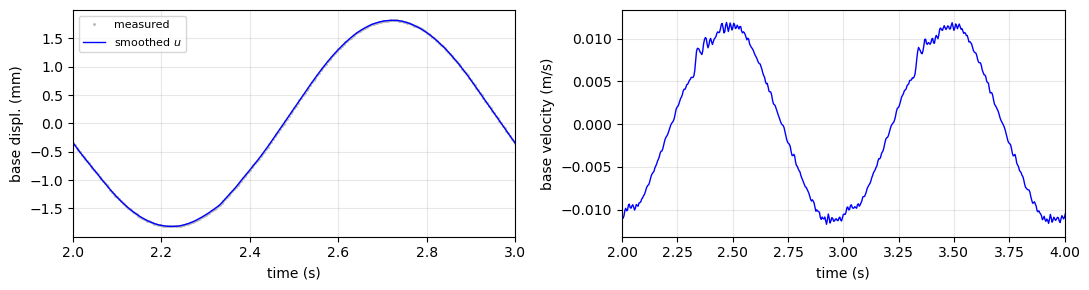

In [5]:
def input_kf_loglik(logtheta, t, y, return_states=False):
    '''Constant-acceleration KF (MC-Eq. 38). Returns -loglik, or smoothed states.'''
    sa2, su2 = np.exp(logtheta)
    dt = t[1] - t[0]
    A = np.array([[1.0, dt], [0.0, 1.0]])
    Q = sa2*np.array([[dt**4/4, dt**3/2], [dt**3/2, dt**2]])
    Hm = np.array([[1.0, 0.0]])
    m = np.array([y[0], 0.0]); P = np.diag([su2 + 1e-8, 1.0])
    N = len(y)
    ms_ = np.zeros((N, 2)); Ps_ = np.zeros((N, 2, 2))
    mp_ = np.zeros((N, 2)); Pp_ = np.zeros((N, 2, 2))
    ll = 0.0
    for k in range(N):
        if k > 0:
            m = A @ m; P = A @ P @ A.T + Q
        mp_[k], Pp_[k] = m, P
        Sv = (Hm @ P @ Hm.T)[0, 0] + su2
        v = y[k] - (Hm @ m)[0]
        ll += -0.5*(np.log(2*np.pi*Sv) + v*v/Sv)
        Kg = (P @ Hm.T)/Sv
        m = m + Kg[:, 0]*v; P = P - Kg @ Hm @ P
        ms_[k], Ps_[k] = m, P
    if not return_states:
        return -ll
    for k in range(N-2, -1, -1):                       # RTS smoother
        G = Ps_[k] @ A.T @ np.linalg.inv(Pp_[k+1])
        ms_[k] = ms_[k] + G @ (ms_[k+1] - mp_[k+1])
        Ps_[k] = Ps_[k] + G @ (Ps_[k+1] - Pp_[k+1]) @ G.T
    return ms_, Ps_


def estimate_input(t, u_noisy, nsub=1000):
    '''MLE of (sigma_a^2, sigma_u^2) on a subset, then smooth the full record.'''
    res = minimize(input_kf_loglik, np.log([1.0, 1e-10]), args=(t[:nsub], u_noisy[:nsub]),
                   method="Nelder-Mead", options=dict(maxiter=100, xatol=1e-2, fatol=1e-2))
    msm, _ = input_kf_loglik(res.x, t, u_noisy, return_states=True)
    return msm[:, 0], msm[:, 1], np.exp(res.x)

u, du, th_in = estimate_input(t, u_noisy)
print(f"base-motion hyperparameters: sigma_a^2 = {th_in[0]:.3e} (m/s^2)^2, "
      f"sigma_u^2 = {th_in[1]:.3e} m^2")

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(t, 1e3*u_noisy, '.', color='0.7', ms=2, label='measured')
ax[0].plot(t, 1e3*u, 'b', label='smoothed $u$')
ax[0].set(xlim=(2, 3), xlabel='time (s)', ylabel='base displ. (mm)'); ax[0].legend(fontsize=8)
ax[1].plot(t, du, 'b'); ax[1].set(xlim=(2, 4), xlabel='time (s)', ylabel='base velocity (m/s)')
plt.tight_layout(); plt.show()

## 5. Step 2 — hyperparameter estimation

We now assemble the full switching model with the **initial-guess parameters** $\hat m = 3.0799$ kg, $\hat c = 5$ Ns/m, $\hat k = 1250$ N/m (MC-Table 7) and maximise the ADF log marginal likelihood over $\boldsymbol\theta = (\sigma_f^2, \ell, \sigma_n^2)$. To keep the optimisation fast we use the first 5 s of data (the response is periodic, so this loses little information) and optimise in log-space.

In [ ]:
M_est, C_est, K_est = 3.0799, 5.0, 1250.0    # mass known; c, k rough guesses (MC-Table 7)

def run_inference(theta, t, z, u, du, M, C, K, rho=0.92):
    dt = t[1] - t[0]
    models, H, sig_n2 = build_models(theta, M, C, K, dt)
    Pi = markov_matrix(rho)
    U = np.column_stack([u, du])
    m0 = np.array([z[0], 0.0, 0.0]); P0 = np.diag([1e-8, 1e-4, 1.0])
    mf, Pf, w, ll = adf_filter(z, U, models, H, sig_n2, Pi, m0, P0)
    return mf, Pf, w, ll, models, H, Pi, U

def neg_loglik(logtheta, t, z, u, du, M, C, K):
    try:
        ll = run_inference(np.exp(logtheta), t, z, u, du, M, C, K)[3]
    except Exception:
        return 1e12
    return -ll if np.isfinite(ll) else 1e12

nsub = 1251                                   # first 5 s for hyperparameter tuning
x0 = np.log([4.0, 1.0, 1e-10])                # (sig_f2 [N^2], ell [s], sig_n2 [m^2])
res = minimize(neg_loglik, x0, args=(t[:nsub], z_obs[:nsub], u[:nsub], du[:nsub],
               M_est, C_est, K_est), method="Nelder-Mead",
               options=dict(maxiter=80, xatol=0.05, fatol=0.5))
theta = np.exp(res.x)
print(f"optimal hyperparameters ({res.nfev} likelihood evaluations):")
print(f"  sig_f^2 = {theta[0]:.3f} N^2   (GP force variance)")
print(f"  ell     = {theta[1]:.3f} s     (GP time-scale)")
print(f"  sig_n^2 = {theta[2]:.3e} m^2 -> noise std {1e6*np.sqrt(theta[2]):.1f} micrometres")

## 6. Step 3 — inference of states, friction force and motion regimes

Run the ADF filter over the full 10 s record, then the EC smoother, and reproduce the paper's key result (MC-Fig. 18): displacement, velocity, reconstructed acceleration, **friction force with its 3σ credible band**, and the inferred regime sequence.

The acceleration is not a state, but follows from the model: $\ddot{\hat z} = \big(k u + c\dot u - k \hat z - c\dot{\hat z} - \hat f\big)/m$, with variance $C_a \Sigma C_a^\top$, $C_a = [-k/m, -c/m, -1/m]$.

In [ ]:
mf, Pf, w, ll, models, H, Pi, U = run_inference(theta, t, z_obs, u, du, M_est, C_est, K_est)
ms, Ps, ws = ec_smoother(z_obs, U, models, H, theta[2], Pi, mf, Pf, w)
m_sm, P_sm = collapse_mixture(ms, Ps, ws)
regime = ws.argmax(axis=1) + 1                     # 1 slide, 2 stick, 3 reset

zh, zdh, fh = m_sm[:, 0], m_sm[:, 1], m_sm[:, 2]
# clip tiny negative variances from the mixture collapse before taking sqrt
sz, sv, sf = [np.sqrt(np.maximum(P_sm[:, i, i], 0)) for i in range(3)]
Ca = np.array([-K_est/M_est, -C_est/M_est, -1.0/M_est])
acc = (K_est*u + C_est*du)/M_est + m_sm @ Ca
sa = np.sqrt(np.maximum(np.einsum('i,nij,j->n', Ca, P_sm, Ca), 0))
print(f"log marginal likelihood = {ll:.1f}")
print("regime occupancy: slide %d, stick %d, reset %d samples"
      % tuple(np.bincount(regime, minlength=4)[1:]))

fig, ax = plt.subplots(5, 1, figsize=(11, 11), sharex=True)
ax[0].plot(t, 1e3*z_obs, 'k', lw=0.8, label='measured')
ax[0].plot(t, 1e3*zh, 'r--', lw=0.8, label='estimated (mean)')
ax[0].fill_between(t, 1e3*(zh-3*sz), 1e3*(zh+3*sz), color='r', alpha=0.2)
ax[0].set_ylabel('displ. (mm)'); ax[0].legend(loc='upper right', fontsize=8)
ax[1].plot(t, zdh, 'r', lw=0.8)
ax[1].fill_between(t, zdh-3*sv, zdh+3*sv, color='r', alpha=0.2)
ax[1].set_ylabel('velocity (m/s)')
ax[2].plot(t, acc, 'r', lw=0.8)
ax[2].fill_between(t, acc-3*sa, acc+3*sa, color='r', alpha=0.2)
ax[2].set_ylabel('accel. (m/s$^2$)')
ax[3].plot(t, fh, 'b', lw=0.8)
ax[3].fill_between(t, fh-3*sf, fh+3*sf, color='b', alpha=0.2)
ax[3].set_ylabel('friction force (N)')
ax[4].plot(t, regime, 'b.', ms=2)
ax[4].set(ylabel='regime', yticks=[1, 2, 3], yticklabels=['slide', 'stick', 'reset'],
          xlabel='time (s)')
fig.suptitle('Switching GPLFM inference on the 550 g record (cf. MC-Fig. 18)', y=0.995)
plt.tight_layout(); plt.show()

### What just happened?

Without ever being told a friction law, the model has produced:

* a **denoised displacement** that tracks the measurement inside a tight credible band,
* a **velocity estimate** that is exactly zero during the stops (enforced by the sticking model when the data supports it) — far cleaner than numerically differentiating the noisy signal,
* the **friction force time history**, showing the classic pattern: during stick the force ramps as it balances the changing elastic force; at break-away it has reached the static limit; during slip it is roughly constant at the kinetic level with a sign given by the sliding direction — and it **jumps** at regime transitions via the resetting model,
* the **stick/slip regime sequence** — measured, not assumed.

This is the "grey-box" pay-off: the physics-based part (mass-spring-damper) explains what it can, and the GP latent force absorbs exactly the part of the dynamics the linear model cannot explain — which, by construction, *is* the friction force (plus any parameter error, which we deal with next).

## 7. Step 4 — correcting the physical parameters

If our guesses $\hat c, \hat k$ are wrong, the latent force absorbs the *linear* residuals too *(MC-Eqs. 27–30)*: the identified force becomes $F_L = F_f + \Delta k\,(z - u) + \Delta c\,(\dot z - \dot u)$ for the base-excited system *(MC-Eq. 37)*. Because Coulomb friction is **antisymmetric** ($F_f(-z,-\dot z) = -F_f(z,\dot z)$) while the error terms are linear, we can separate them:

1. keep only **sliding samples** (regime 1, $|\dot z| >$ tol),
2. **fold** the negative branch onto the positive one (flip the sign of all quantities where $F_L < 0$) — friction now appears as an almost-constant offset $F_0$,
3. fit $F_L \approx F_0 + A_1 (z-u) + A_2 (\dot z - \dot u)$ by least squares; then $\Delta k = A_1$, $\Delta c = A_2$ *(MC-Eq. 32 with $\Delta m = 0$)*.

We then **re-run** hyperparameter estimation and inference with the corrected parameters (the paper follows the same two-pass strategy).

In [ ]:
def fold_correction(zh, zdh, fh, u, du, regime, tol=1e-2):
    '''Linear parameter-error fit on folded sliding samples (MC-Eq. 37 and authors' code).'''
    sl = (regime == 1) & (np.abs(zdh) > tol)
    ff, dd, vv = fh[sl].copy(), zh[sl].copy(), zdh[sl].copy()
    uu, duu = u[sl].copy(), du[sl].copy()
    neg = ff < 0
    for a in (dd, vv, uu, duu, ff):
        a[neg] *= -1                     # fold negative branch onto positive
    keep = vv >= 0
    dd, vv, uu, duu, ff = dd[keep], vv[keep], uu[keep], duu[keep], ff[keep]
    X = np.column_stack([np.ones_like(ff), dd - uu, vv - duu])
    coef, *_ = np.linalg.lstsq(X, ff, rcond=None)
    return coef, len(ff)

coef, nsl = fold_correction(zh, zdh, fh, u, du, regime)
K_corr, C_corr = K_est + coef[1], C_est + coef[2]
print(f"pass 1: {nsl} sliding samples -> Delta_k = {coef[1]:+.1f} N/m, "
      f"Delta_c = {coef[2]:+.2f} Ns/m")
print(f"corrected: k = {K_corr:.1f} N/m, c = {C_corr:.3f} Ns/m")

# --- pass 2: re-tune hyperparameters and re-infer with corrected parameters
res2 = minimize(neg_loglik, np.log(theta), args=(t[:nsub], z_obs[:nsub], u[:nsub],
                du[:nsub], M_est, C_corr, K_corr), method="Nelder-Mead",
                options=dict(maxiter=40, xatol=0.05, fatol=0.5))
theta2 = np.exp(res2.x)
mf, Pf, w, ll2, models, H, Pi, U = run_inference(theta2, t, z_obs, u, du,
                                                 M_est, C_corr, K_corr)
ms, Ps, ws = ec_smoother(z_obs, U, models, H, theta2[2], Pi, mf, Pf, w)
m_sm, P_sm = collapse_mixture(ms, Ps, ws)
regime = ws.argmax(axis=1) + 1
zh, zdh, fh = m_sm[:, 0], m_sm[:, 1], m_sm[:, 2]
sf = np.sqrt(P_sm[:, 2, 2])
coef2, _ = fold_correction(zh, zdh, fh, u, du, regime)
print(f"pass 2: residual Delta_k = {coef2[1]:+.2f} N/m, Delta_c = {coef2[2]:+.3f} Ns/m "
      "(small -> converged)")

fn = np.sqrt(K_corr/M_est)/(2*np.pi); zeta = C_corr/(2*np.sqrt(K_corr*M_est))
print("\n                superimposed-guess  ->  corrected   (hammer test, MC-Table 7)")
print(f"  stiffness   :      1250        ->  {K_corr:7.1f}    (1197 N/m)")
print(f"  visc. damp. :         5        ->  {C_corr:7.3f}    (0.30 Ns/m)")
print(f"  nat. freq.  :                      {fn:7.3f}    (3.137 Hz)")
print(f"  damping ratio:                     {zeta:7.4f}    (0.0018)")

pass 2: residual Delta_k = -0.68 N/m, Delta_c = -0.038 Ns/m (small -> converged)

                superimposed-guess  ->  corrected   (hammer test, MC-Table 7)
  stiffness   :      1250        ->   1206.2    (1197 N/m)
  visc. damp. :         5        ->    2.600    (0.30 Ns/m)
  nat. freq.  :                        3.150    (3.137 Hz)
  damping ratio:                      0.0213    (0.0018)


The stiffness lands within ~1 % of the hammer-test value, exactly as in the paper (which obtained $k = 1191$ N/m). The viscous damping remains overestimated — the paper's estimate (0.67 Ns/m) shows the same tendency, and MC-§4.2 notes the value is small enough that its influence on the response is negligible ($\zeta \ll 1\%$). Part of the apparent "viscous" damping is really velocity-dependence of the friction itself (the Stribeck effect we quantify next); a truly rate-independent Coulomb contact plus small material damping is difficult to separate with only 10 s of data.

## 8. Step 5 — characterising the friction law

The identified force/state/regime triplet lets us go beyond a time history and extract the **constitutive friction behaviour** (MC-§3.5):

* **Force–velocity map:** scatter of $\hat F_f$ vs $\hat{\dot z}$ over the sliding samples.
* **Static friction force $F_s$:** stick→slip transitions happen exactly when $|F_f|$ reaches $F_s$ — so we read $|\hat f|$ at the *last sample of each stick phase* (with an outlier-robust average, as in the authors' code).
* **Fitted friction law:** following the paper we fit the steady-state **Dieterich–Ruina** rate-dependent law *(MC-Eq. 20, from rock mechanics: Dieterich 1979, Rice & Ben-Zion 1996, in the formulation of Cabboi et al. 2022)*:
$$F_f(\dot z) = \Big[F^* + a \ln\frac{|\dot z| + \varepsilon}{V^*} + b \ln\Big(c_{DR} + \frac{V^*}{|\dot z| + \varepsilon}\Big)\Big]\,\mathrm{sgn}(\dot z),$$
with $V^* = 3\times10^{-3}$ m/s, $\varepsilon = 10^{-6}$ m/s fixed, and the static-friction **constraint** *(MC-Eq. 26)* $b = a + (\hat F_s - F^*)/\ln(V^*/\varepsilon)$, leaving $(F^*, a, c_{DR})$ free.
* **Simple Coulomb fit:** the mean sliding force amplitude $F_c$, giving the kinetic friction coefficient $\mu_k = F_c/N$.

In [ ]:
N_load = 0.550*9.81      # applied normal force (N) for the 550 g disc setting

# --- static friction from stick->slip transitions (authors' recipe)
F0m = np.mean(np.abs(fh[regime == 1]))            # mean sliding amplitude
nxt = np.r_[regime[1:], 0]
cand = (regime == 2) & (nxt != 2) & (np.abs(fh) > F0m)   # last sample of each stick phase
vals = np.abs(fh[cand])
med = np.median(vals); mad = np.median(np.abs(vals - med))
good = np.abs(vals - med) < 3*1.4826*mad if mad > 0 else np.ones_like(vals, bool)
Fs, Fs_std = vals[good].mean(), vals[good].std()
print(f"static friction  Fs = {Fs:.3f} +/- {Fs_std:.3f} N  ({good.sum()} break-away events)")
print(f"kinetic (Coulomb) F_c = {F0m:.3f} N")
print(f"friction coefficients: mu_s = {Fs/N_load:.3f}, mu_k = {F0m/N_load:.3f} "
      "(brass on steel: handbook range ~0.3-0.5)")

# --- constrained Dieterich-Ruina fit on folded sliding samples (MC-Eqs. 20, 26)
Vstar, eps_v = 3e-3, 1e-6
sl = (regime == 1) & (np.abs(zdh) > 1e-2)
v_s, f_s = np.abs(zdh[sl]), np.abs(fh[sl])

def dr_constrained(v, Fstar, a, cdr):
    b = a + (Fs - Fstar)/np.log(Vstar/eps_v)
    return Fstar + a*np.log((v + eps_v)/Vstar) + b*np.log(cdr + Vstar/(v + eps_v))

popt, pcov = curve_fit(dr_constrained, v_s, f_s, p0=[F0m, 0.04, 0.02],
                       bounds=([0.8*F0m, 0, 0], [1.2*F0m, 0.1, 0.1]), maxfev=20000)
b_fit = popt[1] + (Fs - popt[0])/np.log(Vstar/eps_v)
print(f"\nDieterich-Ruina fit: F* = {popt[0]:.3f} N, a = {popt[1]:.4f}, "
      f"c_DR = {popt[2]:.4f}, (b = {b_fit:.4f})")

vg = np.linspace(1e-4, 1.1*v_s.max(), 400)
plt.figure(figsize=(7, 5))
plt.plot(zdh[sl], fh[sl], '.', color='m', ms=3, alpha=0.4, label='switching GPLFM estimates')
plt.plot(vg, dr_constrained(vg, *popt), 'g', lw=2, label='Dieterich-Ruina fit')
plt.plot(-vg, -dr_constrained(vg, *popt), 'g', lw=2)
plt.axhline(F0m, color='r', ls='--', lw=1, label='Coulomb $F_c$')
plt.axhline(-F0m, color='r', ls='--', lw=1)
plt.errorbar([0], [Fs], yerr=[[3*Fs_std], [3*Fs_std]], fmt='ks', capsize=4,
             label='static $\\hat F_s \\pm 3\\sigma$')
plt.xlabel('sliding velocity (m/s)'); plt.ylabel('friction force (N)')
plt.title('Identified friction law, 550 g normal load (cf. MC-Fig. 19)')
plt.legend(fontsize=8); plt.show()

The force–velocity cloud shows the **Stribeck effect**: the friction force *decreases* slightly as sliding speed grows, dropping from the static value at break-away toward the kinetic plateau — the same monotonic decreasing pattern reported in MC-Fig. 19 and in Cabboi et al. (2022) for metal contacts. The Dieterich–Ruina law captures it; a plain Coulomb model is a horizontal line through the middle of the cloud.

## 9. Error metrics — how good is the identification?

With experimental data there is **no ground-truth friction force**, so we assess quality with the metrics used in the paper plus standard ones:

* **Normalised mean-square error** *(MC-Eq. 24)* for any quantity $g$ with estimate $\hat g$:
$$\mathrm{NMSE}[g] = \frac{1}{T\sigma_g^2}\sum_{t=1}^{T}\big(g_t - \mathbb E(\hat g_t)\big)^2$$
(0 = perfect; 1 = no better than predicting the mean). Computable against the *measured displacement*.
* **Normalised mean variance** *(MC-Eq. 25)*: $\mathrm{NMV}[g] = \frac{1}{T\sigma_g^2}\sum_t \mathbb V(\hat g_t)$ — how tight the credible bands are.
* **RMSE / MAE** in physical units, for engineering interpretability.
* **Forward-prediction NMSE** — the decisive test: simulate the SDOF system *from scratch* with the **fitted friction law** and corrected parameters, driven by the measured base motion, and compare the simulated displacement with the measurement. This validates the whole identified model, not just the state estimate. (The paper reports NMSE = 0.43 % for this test.)

In [ ]:
def nmse(g_true, g_est):
    return np.mean((g_true - g_est)**2)/np.var(g_true)

def rmse(g_true, g_est):
    return np.sqrt(np.mean((g_true - g_est)**2))

# --- identification metrics (vs measured displacement)
print(f"NMSE[z]  (smoothed vs measured) = {100*nmse(z_obs, zh):.4f} %   "
      "(paper: 4.9e-4 %)")
print(f"RMSE[z]  = {1e6*rmse(z_obs, zh):.1f} micrometres")
print(f"MAE[z]   = {1e6*np.mean(np.abs(z_obs - zh)):.1f} micrometres")
print(f"NMV[F_f] (credible-band tightness) = {100*np.mean(P_sm[:, 2, 2])/np.var(fh):.2f} %")

# --- forward validation: simulate with the FITTED friction law only
u_f = interp1d(t, u, kind="cubic", fill_value="extrapolate")
du_f = interp1d(t, du, kind="cubic", fill_value="extrapolate")
v_reg = 1e-4          # sgn regularisation velocity (m/s)

def simulate(friction_fun, K, C, t_eval, z0):
    def rhs(tt, y):
        zz, vv = y
        acc = (K*u_f(tt) + C*du_f(tt) - K*zz - C*vv - friction_fun(vv))/M_est
        return [vv, acc]
    sol = solve_ivp(rhs, (t_eval[0], t_eval[-1]), [z0, 0.0], t_eval=t_eval,
                    method="LSODA", max_step=dt, rtol=1e-6, atol=1e-9)
    return sol.y[0]

fric_dr = lambda vv: dr_constrained(abs(vv), *popt)*np.tanh(vv/v_reg)
fric_coul = lambda vv: F0m*np.tanh(vv/v_reg)

z_sim_dr = simulate(fric_dr, K_corr, C_corr, t, z_obs[0])
z_sim_cl = simulate(fric_coul, K_corr, C_corr, t, z_obs[0])
print(f"\nforward-prediction NMSE, Dieterich-Ruina law : {100*nmse(z_obs, z_sim_dr):.3f} %"
      "   (paper: 0.43 %)")
print(f"forward-prediction NMSE, Coulomb law         : {100*nmse(z_obs, z_sim_cl):.3f} %")

plt.figure(figsize=(11, 3.2))
plt.plot(t, 1e3*z_obs, 'k', lw=1, label='measured')
plt.plot(t, 1e3*z_sim_dr, 'g--', lw=1, label='simulated, fitted DR law')
plt.plot(t, 1e3*z_sim_cl, 'r:', lw=1, label='simulated, Coulomb law')
plt.xlabel('time (s)'); plt.ylabel('displacement (mm)')
plt.title('Forward validation: response predicted by the identified friction model')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 10. Varying the normal load — does the identification make physical sense?

A crucial sanity check, and the actual engineering deliverable: repeat the identification for all four normal-load settings and verify **Amontons' law** ($F_c \propto N$, constant $\mu$). This is exactly the check in MC-Fig. 19, where the identified force–velocity curves for 2.5–5.5 N are "almost equally spaced".

*(This cell re-runs the full pipeline four times — allow a couple of minutes.)*

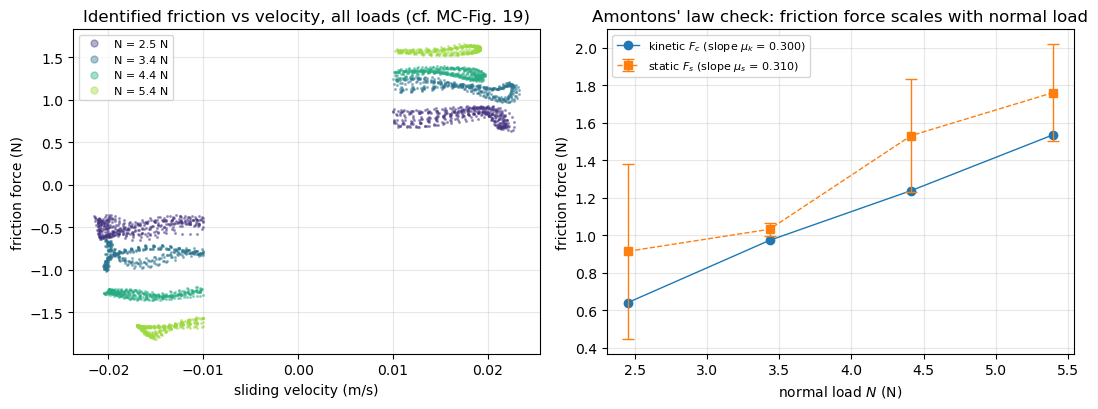

In [ ]:
results = {}
for wgt in (250, 350, 450, 550):
    tt, zz, uu_n = load_case(wgt)
    uu, duu, _ = estimate_input(tt, uu_n)
    r = minimize(neg_loglik, np.log(theta2), args=(tt[:nsub], zz[:nsub], uu[:nsub],
                 duu[:nsub], M_est, C_corr, K_corr), method="Nelder-Mead",
                 options=dict(maxiter=25, xatol=0.05, fatol=0.5))
    th = np.exp(r.x)
    mf_, Pf_, w_, _, mo_, H_, Pi_, U_ = run_inference(th, tt, zz, uu, duu,
                                                      M_est, C_corr, K_corr)
    ms_, Ps_, ws_ = ec_smoother(zz, U_, mo_, H_, th[2], Pi_, mf_, Pf_, w_)
    m_, P_ = collapse_mixture(ms_, Ps_, ws_)
    rg_ = ws_.argmax(axis=1) + 1
    zd_, f_ = m_[:, 1], m_[:, 2]
    F0_ = np.mean(np.abs(f_[rg_ == 1]))
    nx_ = np.r_[rg_[1:], 0]
    va_ = np.abs(f_[(rg_ == 2) & (nx_ != 2) & (np.abs(f_) > F0_)])
    me_ = np.median(va_); ma_ = np.median(np.abs(va_ - me_))
    gd_ = np.abs(va_ - me_) < 3*1.4826*ma_ if ma_ > 0 else np.ones_like(va_, bool)
    N_ = wgt/1000*9.81
    results[wgt] = dict(N=N_, Fc=F0_, Fs=va_[gd_].mean(), Fs_std=va_[gd_].std(),
                        z=m_[:, 0], v=zd_, f=f_, rg=rg_)
    print(f"{wgt} g:  N = {N_:.2f} N   F_c = {F0_:.3f} N   "
          f"Fs = {va_[gd_].mean():.3f} N   mu_k = {F0_/N_:.3f}   "
          f"mu_s = {va_[gd_].mean()/N_:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, 4))
for cc, (wgt, rr) in zip(colors, results.items()):
    sl_ = (rr['rg'] == 1) & (np.abs(rr['v']) > 1e-2)
    ax[0].plot(rr['v'][sl_], rr['f'][sl_], '.', color=cc, ms=2.5, alpha=0.4,
               label=f"N = {rr['N']:.1f} N")
ax[0].set(xlabel='sliding velocity (m/s)', ylabel='friction force (N)',
          title='Identified friction vs velocity, all loads (cf. MC-Fig. 19)')
ax[0].legend(fontsize=8, markerscale=4)

Ns = np.array([results[wg]['N'] for wg in results])
Fcs = np.array([results[wg]['Fc'] for wg in results])
Fss = np.array([results[wg]['Fs'] for wg in results])
Fstd = np.array([results[wg]['Fs_std'] for wg in results])
mu_k_fit = np.polyfit(Ns, Fcs, 1)[0]
mu_s_fit = np.polyfit(Ns, Fss, 1)[0]
ax[1].plot(Ns, Fcs, 'o-', label=f'kinetic $F_c$ (slope $\\mu_k$ = {mu_k_fit:.3f})')
ax[1].errorbar(Ns, Fss, yerr=3*Fstd, fmt='s--', capsize=4,
               label=f'static $F_s$ (slope $\\mu_s$ = {mu_s_fit:.3f})')
ax[1].set(xlabel='normal load $N$ (N)', ylabel='friction force (N)',
          title="Amontons' law check: friction force scales with normal load")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The identified kinetic and static friction forces grow **linearly with normal load** and the curves in the left panel are near-equally spaced — the identification is discovering consistent contact physics from four independent experiments, with friction coefficients in the handbook range for brass on steel. This is the paper's conclusion too, and it is the kind of *validated, uncertainty-quantified friction law* a turbomachinery analyst can take into a forced-response code.

## 11. An alternative SOTA strategy: physics-enhanced sparse identification (PhI-SINDy)

**Sparse Identification of Nonlinear Dynamics** (SINDy, Brunton et al., 2016) takes a different philosophy: instead of inferring the force as a *state*, it selects a **parsimonious symbolic model** from a library of candidate terms by sparse regression. 

For discontinuous friction the plain algorithm struggles, which led Lathourakis & Cicirello (2024) to propose **PhI-SINDy**, tested on *this same experimental rig*: 

it embeds known physics (mass, base-excitation structure), 
includes discontinuous candidates such as $\mathrm{sgn}(\dot z)$, a
nd handles stick-slip within an RK4-SINDy integration scheme, 
with code at [github.com/xristosl0610/PhI-SINDy](https://github.com/xristosl0610/PhI-SINDy).

Here we implement its **core idea in simplified form**, on the same data, via the *restoring force surface* route (Masri & Caughey, 1979; Worden & Tomlinson, 2001):

1. From the measured displacement, obtain $\dot z, \ddot z$ by **Savitzky–Golay** filtering/differentiation (this is the step the GPLFM does probabilistically — here it is deterministic signal processing and the main noise-sensitivity of the method).
2. Compute the **residual force** — everything the known linear physics does not explain:
$$F_{res}(t) = k u + c \dot u - m\ddot z - c\dot z - k z \; \approx \; F_f(t).$$
3. Regress $F_{res}$ on a **physics-informed candidate library** $\Theta(z, \dot z) = [\mathrm{sgn}(\dot z),\ \dot z,\ z]$ (Coulomb term, viscous residual, stiffness residual) with **STLSQ** — sequentially thresholded least squares, the SINDy workhorse — using sliding samples only ($|\dot z| >$ tol), since during stick $F_{res}$ is governed by the balance condition, not a function of $(z,\dot z)$. Two practical details that matter:
   * **normalise the library columns** before thresholding — the raw columns have wildly different scales (|sgn| = 1 vs $|z|\sim10^{-3}$), so an un-normalised threshold is meaningless;
   * **keep the library low-collinearity.** Over the narrow slip-velocity band of this test (0.01–0.02 m/s), Stribeck-shaped candidates like $\mathrm{sgn}(\dot z)\ln(1+|\dot z|/V^*)$ are almost proportional to $\mathrm{sgn}(\dot z)$; including them (or $\dot z^3$) lets the regression split the friction force across several near-collinear columns with huge, physically meaningless coefficients — we verified that the resulting model diverges under forward simulation (NMSE > 200 %!). Handling richer libraries robustly is precisely what the ensemble/physics-bias machinery of full PhI-SINDy is for.

A sparse solution should select $\mathrm{sgn}(\dot z)$ with coefficient $\approx F_c$.

In [ ]:
# back to the 550 g record
win = 15                              # SG window: ~60 ms, shorter than a slip phase
z_sg = savgol_filter(z_obs, win, 3)
v_sg = savgol_filter(z_obs, win, 3, deriv=1, delta=dt)
a_sg = savgol_filter(z_obs, win, 3, deriv=2, delta=dt)
F_res = K_corr*u + C_corr*du - M_est*a_sg - C_corr*v_sg - K_corr*z_sg

lib_names = ["sgn(v)", "v", "z"]
Theta = np.column_stack([np.sign(v_sg), v_sg, z_sg])
mask = np.abs(v_sg) > 1e-2            # sliding samples only

def stlsq(Th, y, lam=0.1, n_iter=15):
    '''Sequentially thresholded least squares (Brunton et al., 2016),
    with column normalisation; threshold relative to the largest coefficient.'''
    nrm = np.linalg.norm(Th, axis=0)
    Thn = Th/nrm
    xi, *_ = np.linalg.lstsq(Thn, y, rcond=None)
    for _ in range(n_iter):
        small = np.abs(xi) < lam*np.abs(xi).max()
        xi[small] = 0
        if (~small).sum() == 0:
            break
        xi[~small], *_ = np.linalg.lstsq(Thn[:, ~small], y, rcond=None)
    return xi/nrm

xi = stlsq(Theta[mask], F_res[mask])
print("sparse model for the friction force:")
print("  F_f(z, v) =", " + ".join(f"({c:.3f})*{n}" for c, n in zip(xi, lib_names)
                                  if c != 0))
print(f"\nCoulomb amplitude from sparse regression: {xi[0]:.3f} N")
print(f"switching GPLFM gave                     : F_c = {F0m:.3f} N  "
      f"({100*abs(xi[0]-F0m)/F0m:.1f} % apart)")

# forward validation of the sparse model
def fric_sindy(vv):
    return xi[0]*np.tanh(vv/v_reg) + xi[1]*vv

z_sim_si = simulate(fric_sindy, K_corr, C_corr, t, z_obs[0])
print(f"forward-prediction NMSE, sparse (SINDy-style) model: {100*nmse(z_obs, z_sim_si):.3f} %")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(v_sg[mask], F_res[mask], '.', color='0.6', ms=2, alpha=0.4,
           label='residual-force samples')
ax[0].plot(zdh[sl], fh[sl], '.', color='m', ms=2, alpha=0.3, label='switching GPLFM')
vv_ = np.linspace(-0.025, 0.025, 500)
ax[0].plot(vv_, [fric_sindy(v) for v in vv_], 'b', lw=2, label='sparse model')
ax[0].plot(vg, dr_constrained(vg, *popt), 'g--', lw=1.5, label='GPLFM + DR fit')
ax[0].plot(-vg, -dr_constrained(vg, *popt), 'g--', lw=1.5)
ax[0].set(xlabel='velocity (m/s)', ylabel='friction force (N)',
          title='Friction law: sparse regression vs switching GPLFM')
ax[0].legend(fontsize=7, markerscale=3)
ax[1].plot(t, 1e3*z_obs, 'k', lw=1, label='measured')
ax[1].plot(t, 1e3*z_sim_si, 'b--', lw=1, label='simulated, sparse model')
ax[1].set(xlim=(0, 5), xlabel='time (s)', ylabel='displacement (mm)',
          title='Forward validation of the sparse model')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Comparing the two strategies

| | **Switching GPLFM** (Marino & Cicirello, 2023) | **Physics-informed sparse regression** (PhI-SINDy; simplified here) |
|---|---|---|
| Output | Full posterior: states, force time history **with uncertainty**, regime sequence | Symbolic, sparse friction law with point-estimate coefficients |
| Assumed form of friction | **None** during inference; law fitted afterwards | Restricted to the span of the **candidate library** |
| Discontinuities / stick-slip | Handled natively (switching + resetting models) | Need special treatment (here: masking stick; PhI-SINDy: physics biases + RK4 scheme) |
| Differentiation of noisy data | Avoided — velocity/acceleration inferred probabilistically | Required (SG filters) — main noise sensitivity; PhI-SINDy mitigates with weak/integral forms |
| Static friction $F_s$ | Directly from inferred break-away events | Not directly accessible (stick samples excluded) |
| Uncertainty quantification | Yes (credible bands, NMV) | No (unless bootstrapped / ensemble-SINDy) |
| Cost | Minutes (Kalman recursions × hyperparameter search) | Seconds (filtering + least squares) |
| Extrapolation / use in design | Fitted law + parameters | The identified equation itself — very convenient for HBM codes |

Both strategies **agree on the kinetic friction level** here, which is the strongest cross-validation an experimentalist can ask for: two philosophically different methods, same physics.

## 12. Using the identified friction model in turbomachinery practice

What do you actually *do* with $\mu_k$, $F_s$, and a fitted friction law?

1. **Forced-response prediction.** Friction laws identified at component level are the constitutive input for nonlinear forced-response analyses of bladed discs — usually via the **harmonic balance method** with contact elements (Krack & Gross, 2019; Krack et al., 2017). The normal-load dependence we verified (Amontons scaling) is what lets a designer extrapolate a damper's behaviour across the centrifugal-load range (normal load on an underplatform damper varies with rotor speed²).
2. **Underplatform damper design.** The energy dissipated per vibration cycle by a Coulomb contact with slip amplitude $\Delta$ is $E_{diss} = 4 F_c \Delta$ — directly computable from our identified force–displacement loop (below). Designers tune damper mass/normal load to maximise dissipation at the critical mode without locking the contact (a stuck damper = no damping at all, and higher stiffness). Interface parameters measured/identified in dedicated friction rigs feed these models (Schwingshackl et al., 2012).
3. **Model updating & digital twins.** The regime sequence and credible bands from the GPLFM tell you *when* the model can be trusted; the same grey-box machinery is used for virtual sensing in operating machines (e.g. Bilbao et al., 2022; Zou et al., 2023 for wind turbines).
4. **Condition monitoring.** Fretting wear changes contact parameters over life; re-identifying $\mu$ from vibration data can flag joint degradation without disassembly (Noël & Kerschen, 2017; Brake, 2018).

In [ ]:
# --- energy dissipated per cycle by the identified contact, for every normal load
f_drive = 1.0                       # driving frequency (Hz)
n_cyc = int(np.floor(t[-1]*f_drive))
i_end = int(n_cyc/f_drive/dt)

E_rows = []
for wgt, rr in results.items():
    E_loop = np.trapezoid(rr['f'][:i_end], rr['z'][:i_end])/n_cyc   # (1/n) * loop int F dz
    E_rows.append((rr['N'], E_loop))
E_rows = np.array(E_rows)

Delta = 0.5*(zh.max() - zh.min())          # 550 g slip amplitude
E_550 = E_rows[-1, 1]
print(f"550 g: energy dissipated per cycle (identified loop): {1e3*E_550:.2f} mJ")
print(f"       Coulomb check, 4*Fc*Delta                    : {1e3*4*F0m*Delta:.2f} mJ")

om = 2*np.pi*f_drive
c_eq = E_550/(np.pi*om*Delta**2)           # equivalent viscous damping at 1 Hz
print(f"       equivalent viscous damping c_eq = {c_eq:.0f} Ns/m")
print("NOTE: c_eq is ~100x the structural damping and even exceeds critical damping:")
print("      the contact dominates the dynamics so strongly that the frame is locked")
print("      half the time. Equivalent linearisation is only a rough guide in this")
print("      regime; forced-response codes use the full hysteresis loop (HBM contact")
print("      elements) instead.")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(1e3*zh, fh, lw=0.7)
ax[0].set(xlabel='displacement (mm)', ylabel='friction force (N)',
          title='Identified hysteresis loop (550 g): area = dissipated energy')
ax[1].plot(E_rows[:, 0], 1e3*E_rows[:, 1], 'o-')
ax[1].set(xlabel='normal load $N$ (N)', ylabel='energy per cycle (mJ)',
          title='Damper-design view: dissipation vs normal load')
plt.tight_layout(); plt.show()

**The damper-design trade-off.** Dissipated energy per cycle is the friction damper's figure of merit. It is the product $\sim 4F_c\Delta$ of two competing factors: normal load raises $F_c \;(=\mu_k N)$ but *reduces* the slip amplitude $\Delta$ — at zero load nothing resists (no dissipation), at very high load the contact locks (again no dissipation). The optimum sits in between. Over the range tested here dissipation still grows with $N$, but the growth is already sub-linear — the stick fraction increases with load. In an engine, the normal load on an underplatform damper is set by centrifugal force, so this curve directly informs the choice of **damper mass** for the operating speed range (Krack et al., 2017; Krack & Gross, 2019).

## 13. Summary

* Friction contacts dominate the damping — and much of the uncertainty — of turbomachinery assemblies; their laws must be **identified**, not assumed.
* The **switching GPLFM** infers the friction force as a latent state, with three regime models (slide / stick / reset) and Bayesian inference over states, force, *and* regime sequence, requiring **no assumed friction law**. On real stick-slip data it recovered displacement to NMSE $\sim 10^{-3}\,\%$, corrected wrong stiffness guesses to within ~1 %, and produced friction coefficients that scale correctly with normal load.
* **Error metrics** used: NMSE (identification and forward prediction), NMV (uncertainty tightness), RMSE/MAE — with forward simulation from the fitted law as the decisive validation.
* The **PhI-SINDy-style sparse regression** alternative reaches a compatible Coulomb amplitude at a fraction of the cost, but without uncertainty, without static friction, and only within its candidate library.
* Deliverables for practice: $\mu_k, \mu_s$, a fitted Dieterich–Ruina law, per-cycle dissipation and equivalent damping — direct inputs to harmonic-balance forced-response and damper design.

### Exercises

1. **Persistence prior.** Re-run §6 with $\rho = 0.85$ and $\rho = 0.98$. How do the regime sequence and the friction credible band change? Why does a large $\rho$ smooth over short sticks?
2. **Kernel choice.** Replace the Matérn 1/2 latent force with Matérn 3/2 (state $[f, \dot f]$; see Hartikainen & Särkkä 2010 for the matrices). Does the identified force change appreciably? (MC-§3.2 reports it does not, and 1/2 is cheapest.)
3. **Data budget.** Repeat the identification with only the first 2 s of data. How do NMSE and the $F_s$ scatter degrade? Compare with MC-Fig. 14.
4. **SINDy library.** Add a $\tanh(\dot z/v_0)$ candidate with a few fixed $v_0$ values to the sparse library. Does STLSQ prefer it over $\mathrm{sgn}(\dot z)$? What happens to the forward-prediction NMSE?
5. **Cross-load prediction.** Predict the 350 g response using *only* $\mu_k$ identified at 550 g (i.e. $F_c = \mu_k N_{350}$), simulate, and compute the NMSE. This mimics extrapolating a damper design across rotor speed.

## References

**The method and case study**
- Marino, L. & Cicirello, A. (2023). A switching Gaussian process latent force model for the identification of mechanical systems with a discontinuous nonlinearity. *Data-Centric Engineering*, 4, e18. [doi:10.1017/dce.2023.12](https://doi.org/10.1017/dce.2023.12) — data & MATLAB code: [github.com/l-marino/switching-GPLFM](https://github.com/l-marino/switching-GPLFM)
- Marino, L. & Cicirello, A. (2020). Experimental investigation of a single-degree-of-freedom system with Coulomb friction. *Nonlinear Dynamics*, 99, 1781–1799. [doi:10.1007/s11071-019-05443-2](https://doi.org/10.1007/s11071-019-05443-2)
- Marino, L. & Cicirello, A. (2022). Coulomb friction effect on the forced vibration of damped mass–spring systems. *Journal of Sound and Vibration*, 535, 117085.
- Cabboi, A., Marino, L. & Cicirello, A. (2022). A comparative study between Amontons–Coulomb and Dieterich–Ruina friction laws for the cyclic response of a single degree of freedom system. *European Journal of Mechanics – A/Solids*, 96, 104737.

**Gaussian process latent force models**
- Alvarez, M., Luengo, D. & Lawrence, N.D. (2009). Latent force models. *AISTATS, JMLR W&CP*, 5, 9–16.
- Hartikainen, J. & Särkkä, S. (2010). Kalman filtering and smoothing solutions to temporal Gaussian process regression models. *IEEE MLSP*, 379–384.
- Hartikainen, J. & Särkkä, S. (2012). Sequential inference for latent force models. arXiv:1202.3730.
- Nayek, R., Chakraborty, S. & Narasimhan, S. (2019). A Gaussian process latent force model for joint input-state estimation in linear structural systems. *Mechanical Systems and Signal Processing*, 128, 497–530.
- Rogers, T.J., Worden, K. & Cross, E.J. (2020). On the application of Gaussian process latent force models for joint input-state-parameter estimation. *Mechanical Systems and Signal Processing*, 140, 106580.
- Rogers, T.J. & Friis, T. (2022). A latent restoring force approach to nonlinear system identification. *Mechanical Systems and Signal Processing*, 180, 109426.
- Särkkä, S. & Solin, A. (2019). *Applied Stochastic Differential Equations*. Cambridge University Press.
- Rasmussen, C.E. & Williams, C.K.I. (2006). *Gaussian Processes for Machine Learning*. MIT Press.

**Inference machinery**
- Barber, D. (2006). Expectation correction for smoothed inference in switching linear dynamical systems. *Journal of Machine Learning Research*, 7, 2515–2540.
- Acerbi, L. (2018). Variational Bayesian Monte Carlo. *Advances in Neural Information Processing Systems*, 31, 8222–8232.

**Friction physics**
- Dieterich, J.H. (1979). Modeling of rock friction: 1. Experimental results and constitutive equations. *Journal of Geophysical Research: Solid Earth*, 84, 2161–2168.
- Rice, J.R. & Ben-Zion, Y. (1996). Slip complexity in earthquake fault models. *PNAS*, 93(9), 3811–3818.

**Sparse identification (the SOTA alternative)**
- Lathourakis, C. & Cicirello, A. (2024). Physics enhanced sparse identification of dynamical systems with discontinuous nonlinearities. *Nonlinear Dynamics*, 112, 11237–11264. [doi:10.1007/s11071-024-09652-2](https://doi.org/10.1007/s11071-024-09652-2) — code: [github.com/xristosl0610/PhI-SINDy](https://github.com/xristosl0610/PhI-SINDy)
- Brunton, S.L., Proctor, J.L. & Kutz, J.N. (2016). Discovering governing equations from data by sparse identification of nonlinear dynamical systems. *PNAS*, 113(15), 3932–3937.
- Masri, S.F. & Caughey, T.K. (1979). A nonparametric identification technique for nonlinear dynamic problems. *Journal of Applied Mechanics*, 46(2), 433–447.
- Worden, K. & Tomlinson, G.R. (2001). *Nonlinearity in Structural Dynamics: Detection, Identification and Modelling*. Institute of Physics.
- Noël, J.-P. & Kerschen, G. (2017). Nonlinear system identification in structural dynamics: 10 more years of progress. *Mechanical Systems and Signal Processing*, 83, 2–35.

**Turbomachinery friction applications**
- Schwingshackl, C.W., Petrov, E.P. & Ewins, D.J. (2012). Measured and estimated friction interface parameters in a nonlinear dynamic analysis. *Mechanical Systems and Signal Processing*, 28, 574–584.
- Krack, M., Salles, L. & Thouverez, F. (2017). Vibration prediction of bladed disks coupled by friction joints. *Archives of Computational Methods in Engineering*, 24, 589–636.
- Krack, M. & Gross, J. (2019). *Harmonic Balance for Nonlinear Vibration Problems*. Springer.
- Brake, M.R.W. (ed.) (2018). *The Mechanics of Jointed Structures*. Springer.

**Virtual sensing with GPLFMs (further reading)**
- Bilbao, J., Lourens, E.-M., Schulze, A. & Ziegler, L. (2022). Virtual sensing in an onshore wind turbine tower using a Gaussian process latent force model. *Data-Centric Engineering*, 3, e35.
- Zou, J., Lourens, E.-M. & Cicirello, A. (2023). Virtual sensing of subsoil strain response in monopile-based offshore wind turbines via Gaussian process latent force models. *Mechanical Systems and Signal Processing*, 200, 110488.

---